In [2]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from GaNN.synth import generate
from GaNN.synth import utils 
from GaNN.train.train import train_hnet

%load_ext autoreload
%autoreload 2

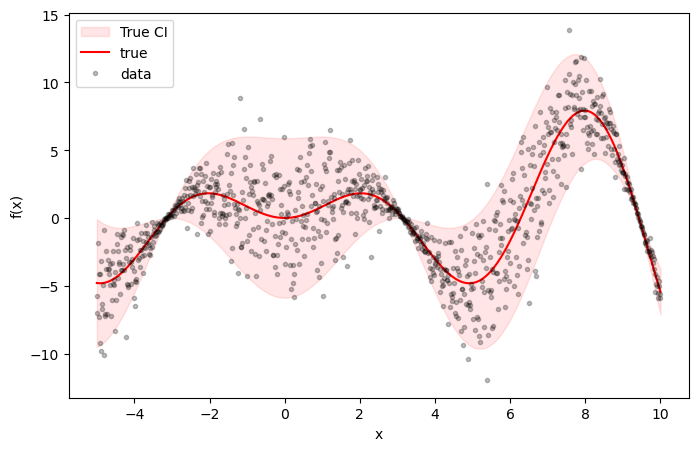

In [3]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [5]:
num_epochs = 1000
samples = 1000 
batch_size = 250
lr = 1e-4
hidden_channels = 50
layers = 2
gaussian_channels = 25
width = 100
compile = False

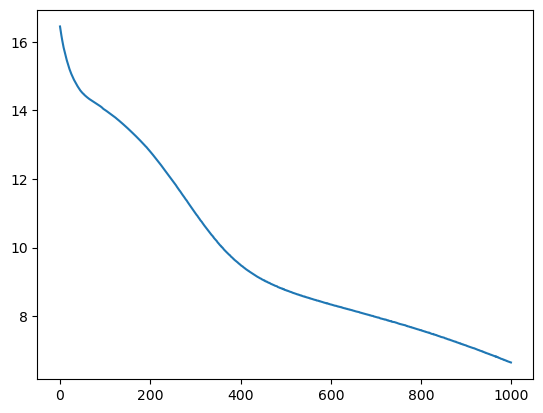

In [6]:
mlp_kwargs = model_kwargs={'hidden_channels':hidden_channels, 
                           'layers':layers}

hnet_kwargs = {'stochastic_channels':gaussian_channels, 
               'width':width}

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn='mse', mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

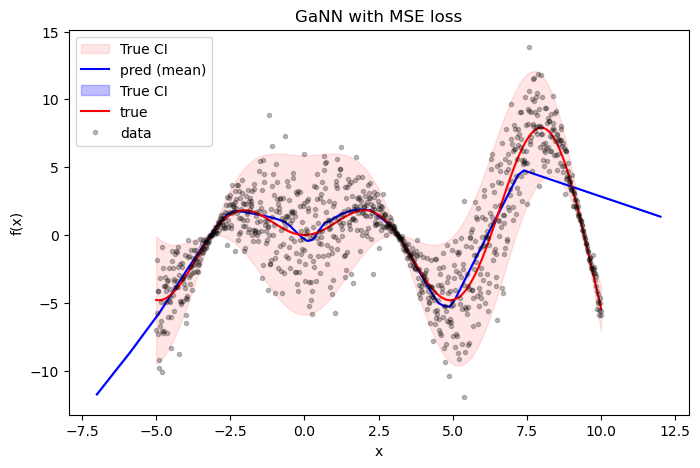

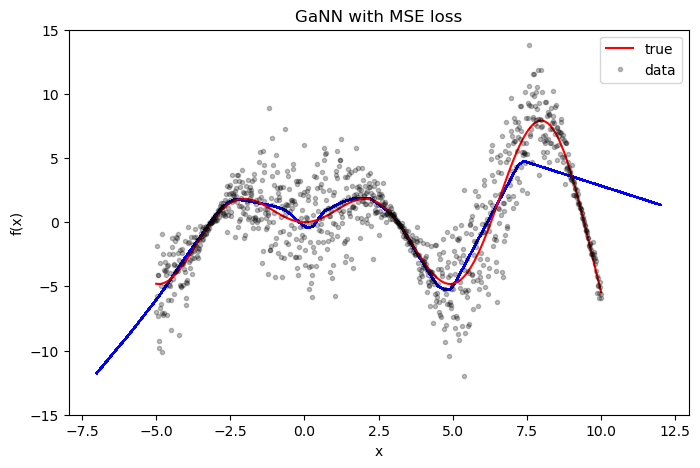

In [7]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with MSE loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with MSE loss', plot_ci=False, ylim=(-15,15))

{'f.0.weight': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]), 'f.0.bias': tensor([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
        86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]), 'f.3.weight': tensor([ 100,  101,  102,  ..., 2597, 2598, 2599]), 'f.3.bias': tensor([2600, 2601, 2602, 2603, 2604, 2605, 2606, 2607, 2608, 2609, 2610, 2611,
        2612, 2613, 2614, 2615, 2616, 2617, 2618, 2619, 2620, 2621, 2622, 2623,
        2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2632, 2633, 2634, 2635,
        2636, 2637, 2638, 2639, 2640, 2641, 2642, 2643, 2644, 2645, 2646, 2647,
        2648, 2649]), 'f.6.weight': tensor([2650, 2651, 2652,  ..., 5147, 5148, 5149]), 'f.6.bias': tensor([5150, 5151, 515

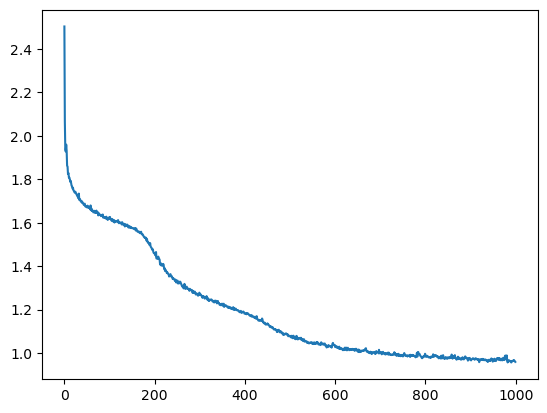

In [10]:
mlp_kwargs = model_kwargs={'hidden_channels':hidden_channels, 
                           'layers':layers}

hnet_kwargs = {'stochastic_channels':gaussian_channels, 
               'width':width}

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn='nll', mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

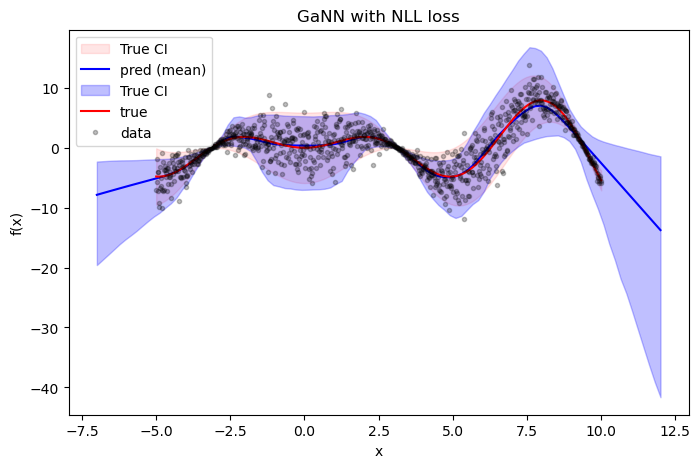

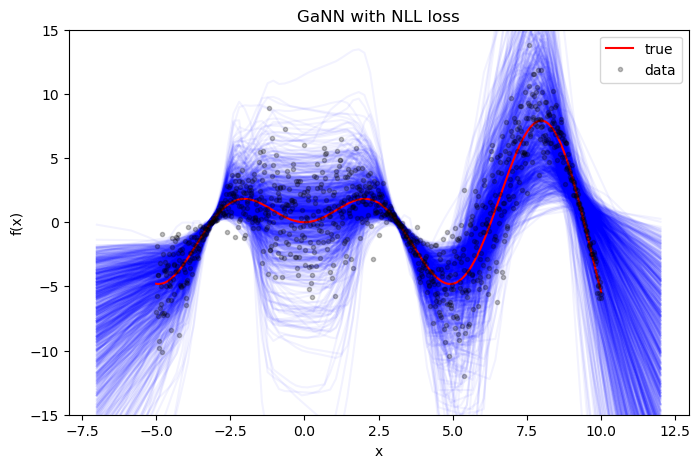

In [11]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss', plot_ci=False, ylim=(-15,15))

In [7]:
# create a symmetric dataset, our method should effectively identify both local minimia 

# use val to select optimal performing z values. 

# quantify epistemic vs aleatoric - 
#   aleatoric = GaNN_MSE - GaNN_NLL
#   epistemic = GaNN_NLL ... ? 